In [7]:
%pip install pandas numpy scikit-learn matplotlib

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [8]:
import pandas as pd
data = pd.read_csv('SPX.csv')

data.head()

,Date,Open,High,Low,Close,Adj Close,Volume
0,1927-12-30,17.660000,17.660000,17.660000,17.660000,17.660000,0
1,1928-01-03,17.760000,17.760000,17.760000,17.760000,17.760000,0
2,1928-01-04,17.719999,17.719999,17.719999,17.719999,17.719999,0
3,1928-01-05,17.549999,17.549999,17.549999,17.549999,17.549999,0
4,1928-01-06,17.660000,17.660000,17.660000,17.660000,17.660000,0


In [9]:
from sklearn.preprocessing import MinMaxScaler

closing_data = data[['Close']].values

scaler = MinMaxScaler(feature_range=(0, 1))

scaled_data = scaler.fit_transform(closing_data)

print(scaled_data[:5])

[[0.0037076 ]
 [0.00373556]
 [0.00372437]
 [0.00367684]
 [0.0037076 ]]


In [10]:
import numpy as np

# We define how many days the LSTM should look back (60 days is standard for stocks)
time_step = 60

X_train = [] # This will hold the "past 60 days" windows
y_train = [] # This will hold the "61st day" targets

# We slide a 60-day window across our entire dataset
for i in range(time_step, len(scaled_data)):
    X_train.append(scaled_data[i-time_step:i, 0])
    y_train.append(scaled_data[i, 0])

# Convert these lists into NumPy arrays because Neural Networks love math matrices
X_train, y_train = np.array(X_train), np.array(y_train)

# CRITICAL STEP: LSTMs require a very specific 3D shape: [Samples, Time Steps, Features]
# Right now, we only have 1 feature (the Close price)
X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], 1))

# Let's check the final dimensions of our data
print("X_train shape (Samples, Time Steps, Features):", X_train.shape)
print("y_train shape (Target Samples):", y_train.shape)

X_train shape (Samples, Time Steps, Features): (23263, 60, 1)
y_train shape (Target Samples): (23263,)


In [11]:
%pip install pandas numpy scikit-learn tensorflow matplotlib

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [12]:
from sklearn.preprocessing import MinMaxScaler

# 1. We grab only the 'Close' prices
closing_data = data[['Close']].values

# 2. Define the machine (The transformation function)
scaler = MinMaxScaler(feature_range=(0, 1))

# 3. Fit the machine to our data and transform it
scaled_data = scaler.fit_transform(closing_data)

# 4. Let's see the first 5 scaled prices
print("First 5 scaled prices:\n", scaled_data[:5])

First 5 scaled prices:
 [[0.0037076 ]
 [0.00373556]
 [0.00372437]
 [0.00367684]
 [0.0037076 ]]


In [13]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, Dropout

# Build the Sequential Model
model = Sequential()

# Layer 1: LSTM with 50 neurons
# return_sequences=True because we want to pass info to the next LSTM layer
model.add(LSTM(units=50, return_sequences=True, input_shape=(60, 1)))
model.add(Dropout(0.2)) # This randomly shuts off 20% of neurons to prevent "memorizing"

# Layer 2: LSTM with 50 neurons
# return_sequences=False because this is the last LSTM layer
model.add(LSTM(units=50, return_sequences=False))
model.add(Dropout(0.2))

# Layer 3: Output Layer
# We want to predict exactly 1 number (tomorrow's price)
model.add(Dense(units=1))

# Compile the Brain
# Optimizer 'adam' uses adaptive learning rates (very efficient for finance)
model.compile(optimizer='adam', loss='mean_squared_error')

print("LSTM Architecture successfully built!")
model.summary()

LSTM Architecture successfully built!


c:\Users\HP\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 60, 50)         │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 60, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,651 (119.73 KB)

 Trainable params: 30,651 (119.73 KB)

 Non-trainable params: 0 (0.00 B)

In [14]:
# The training process
# epochs = 10 means the model will look at the entire dataset 10 times
# batch_size = 32 means it will update its 'brain' after every 32 samples
history = model.fit(X_train, y_train, epochs=10, batch_size=32)

print("\nTraining Complete!")

Epoch 1/10
727/727 ━━━━━━━━━━━━━━━━━━━━ 27s 32ms/step - loss: 0.0012
Epoch 2/10
727/727 ━━━━━━━━━━━━━━━━━━━━ 22s 30ms/step - loss: 4.3058e-04
Epoch 3/10
727/727 ━━━━━━━━━━━━━━━━━━━━ 21s 29ms/step - loss: 3.9353e-04
Epoch 4/10
727/727 ━━━━━━━━━━━━━━━━━━━━ 21s 29ms/step - loss: 3.5271e-04
Epoch 5/10
727/727 ━━━━━━━━━━━━━━━━━━━━ 21s 29ms/step - loss: 3.2851e-04
Epoch 6/10
727/727 ━━━━━━━━━━━━━━━━━━━━ 21s 29ms/step - loss: 3.5393e-04
Epoch 7/10
727/727 ━━━━━━━━━━━━━━━━━━━━ 21s 29ms/step - loss: 3.4912e-04
Epoch 8/10
727/727 ━━━━━━━━━━━━━━━━━━━━ 21s 28ms/step - loss: 3.2800e-04
Epoch 9/10
727/727 ━━━━━━━━━━━━━━━━━━━━ 22s 30ms/step - loss: 3.3985e-04
Epoch 10/10
727/727 ━━━━━━━━━━━━━━━━━━━━ 22s 30ms/step - loss: 3.3724e-04

Training Complete!


727/727 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step


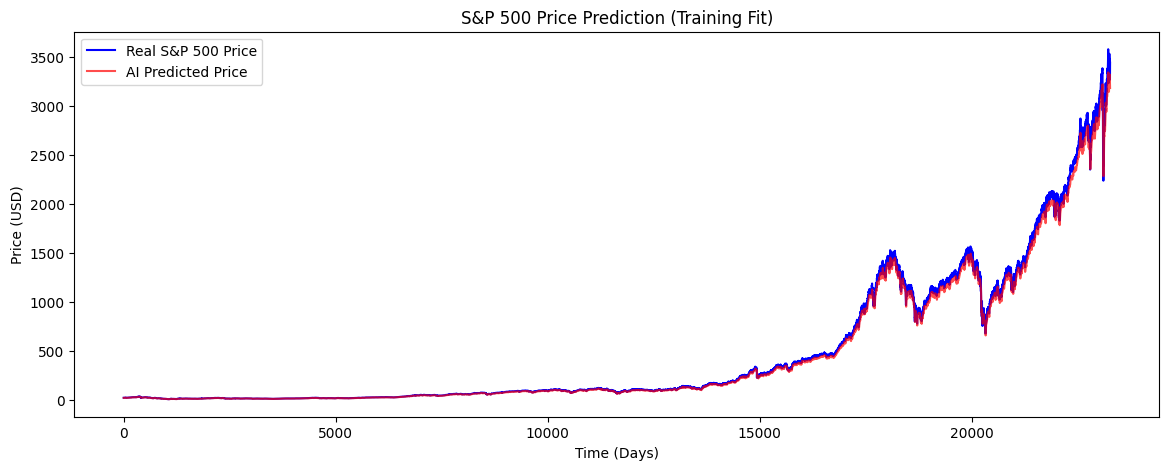

In [15]:
import matplotlib.pyplot as plt

# 1. Let's make predictions on our training set just to see how well it fits
predictions = model.predict(X_train)

# 2. Convert scaled predictions back to actual dollar prices
predictions = scaler.inverse_transform(predictions)
y_train_actual = scaler.inverse_transform(y_train.reshape(-1, 1))

# 3. Create the graph
plt.figure(figsize=(14, 5))
plt.plot(y_train_actual, color='blue', label='Real S&P 500 Price')
plt.plot(predictions, color='red', alpha=0.7, label='AI Predicted Price')
plt.title('S&P 500 Price Prediction (Training Fit)')
plt.xlabel('Time (Days)')
plt.ylabel('Price (USD)')
plt.legend()
plt.show()

In [16]:
# Save the model
model.save('sp500_lstm_model.h5')

# Save the scaler (you need this to un-scale future predictions!)
import joblib
joblib.dump(scaler, 'scaler.gz')

print("Model and Scaler saved successfully! You are officially an AI Developer.")

Model and Scaler saved successfully! You are officially an AI Developer.


In [17]:
# Veriyi ayırma noktası
train_size = int(len(X_train) * 0.8)

X_train_final = X_train[:train_size]
y_train_final = y_train[:train_size]

X_test = X_train[train_size:]
y_test = y_train[train_size:]

print(f"Eğitim verisi: {len(X_train_final)}")
print(f"Test verisi: {len(X_test)}")

Eğitim verisi: 18610
Test verisi: 4653


In [18]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, Dropout

model_deep = Sequential()

# Layer 1
model_deep.add(LSTM(units=100, return_sequences=True, input_shape=(60, 1)))
model_deep.add(Dropout(0.3))

# Layer 2 (Yeni ekledik)
model_deep.add(LSTM(units=100, return_sequences=True))
model_deep.add(Dropout(0.3))

# Layer 3 (Yeni ekledik)
model_deep.add(LSTM(units=50, return_sequences=True))
model_deep.add(Dropout(0.3))

# Layer 4
model_deep.add(LSTM(units=50, return_sequences=False))
model_deep.add(Dropout(0.3))

# Output
model_deep.add(Dense(units=1))

model_deep.compile(optimizer='adam', loss='mean_squared_error')
model_deep.summary()

c:\Users\HP\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                   │ (None, 60, 100)        │        40,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 60, 100)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 60, 100)        │        80,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 60, 100)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_4 (LSTM)                   │ (None, 60, 50)         │        30,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 60, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_5 (LSTM)                   │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 171,651 (670.51 KB)

 Trainable params: 171,651 (670.51 KB)

 Non-trainable params: 0 (0.00 B)

In [19]:
# Bu sefer 20 epoch yapalım, daha derin olduğu için daha çok tura ihtiyacı olabilir
history_deep = model_deep.fit(X_train_final, y_train_final, epochs=20, batch_size=64)

Epoch 1/20
291/291 ━━━━━━━━━━━━━━━━━━━━ 46s 132ms/step - loss: 3.4988e-04
Epoch 2/20
291/291 ━━━━━━━━━━━━━━━━━━━━ 37s 126ms/step - loss: 1.7333e-04
Epoch 3/20
291/291 ━━━━━━━━━━━━━━━━━━━━ 36s 122ms/step - loss: 1.7125e-04
Epoch 4/20
291/291 ━━━━━━━━━━━━━━━━━━━━ 36s 123ms/step - loss: 1.3545e-04
Epoch 5/20
291/291 ━━━━━━━━━━━━━━━━━━━━ 36s 125ms/step - loss: 1.5795e-04
Epoch 6/20
291/291 ━━━━━━━━━━━━━━━━━━━━ 36s 123ms/step - loss: 1.2612e-04
Epoch 7/20
291/291 ━━━━━━━━━━━━━━━━━━━━ 36s 123ms/step - loss: 1.3185e-04
Epoch 8/20
291/291 ━━━━━━━━━━━━━━━━━━━━ 36s 123ms/step - loss: 1.2925e-04
Epoch 9/20
291/291 ━━━━━━━━━━━━━━━━━━━━ 35s 121ms/step - loss: 1.1914e-04
Epoch 10/20
291/291 ━━━━━━━━━━━━━━━━━━━━ 35s 121ms/step - loss: 1.3049e-04
Epoch 11/20
291/291 ━━━━━━━━━━━━━━━━━━━━ 35s 119ms/step - loss: 1.3017e-04
Epoch 12/20
291/291 ━━━━━━━━━━━━━━━━━━━━ 35s 120ms/step - loss: 1.1561e-04
Epoch 13/20
291/291 ━━━━━━━━━━━━━━━━━━━━ 35s 121ms/step - loss: 1.1922e-04
Epoch 14/20
291/291 ━━━━━━━━━━━━━━

146/146 ━━━━━━━━━━━━━━━━━━━━ 5s 31ms/step


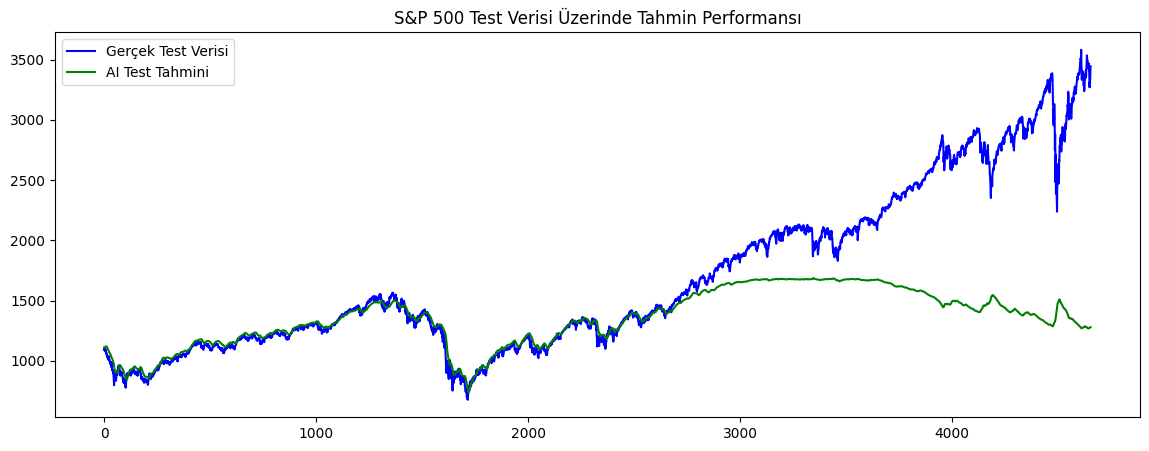

In [20]:
# Test verisiyle tahmin
test_predictions = model_deep.predict(X_test)
test_predictions = scaler.inverse_transform(test_predictions)
y_test_actual = scaler.inverse_transform(y_test.reshape(-1, 1))

# Grafikleştirme
plt.figure(figsize=(14, 5))
plt.plot(y_test_actual, color='blue', label='Gerçek Test Verisi')
plt.plot(test_predictions, color='green', label='AI Test Tahmini')
plt.title('S&P 500 Test Verisi Üzerinde Tahmin Performansı')
plt.legend()
plt.show()

In [21]:
model_optimized = Sequential()

model_optimized.add(LSTM(units=100, return_sequences=True, input_shape=(60, 1)))
model_optimized.add(Dropout(0.1)) # Reduced from 0.3

model_optimized.add(LSTM(units=100, return_sequences=True))
model_optimized.add(Dropout(0.1))

model_optimized.add(LSTM(units=50, return_sequences=False))
model_optimized.add(Dropout(0.1))

model_optimized.add(Dense(units=1))
model_optimized.compile(optimizer='adam', loss='mean_squared_error')

# Let's train for 30 epochs this time to give it time to reach the high prices
history_opt = model_optimized.fit(X_train_final, y_train_final, epochs=30, batch_size=32)

Epoch 1/30


c:\Users\HP\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


582/582 ━━━━━━━━━━━━━━━━━━━━ 38s 57ms/step - loss: 1.4344e-04
Epoch 2/30
582/582 ━━━━━━━━━━━━━━━━━━━━ 32s 56ms/step - loss: 6.2363e-05
Epoch 3/30
582/582 ━━━━━━━━━━━━━━━━━━━━ 34s 58ms/step - loss: 5.8965e-05
Epoch 4/30
582/582 ━━━━━━━━━━━━━━━━━━━━ 33s 57ms/step - loss: 5.5321e-05
Epoch 5/30
582/582 ━━━━━━━━━━━━━━━━━━━━ 33s 56ms/step - loss: 5.2071e-05
Epoch 6/30
582/582 ━━━━━━━━━━━━━━━━━━━━ 33s 56ms/step - loss: 5.4706e-05
Epoch 7/30
582/582 ━━━━━━━━━━━━━━━━━━━━ 33s 56ms/step - loss: 4.2770e-05
Epoch 8/30
582/582 ━━━━━━━━━━━━━━━━━━━━ 33s 56ms/step - loss: 5.3373e-05
Epoch 9/30
582/582 ━━━━━━━━━━━━━━━━━━━━ 33s 56ms/step - loss: 4.4950e-05
Epoch 10/30
582/582 ━━━━━━━━━━━━━━━━━━━━ 32s 56ms/step - loss: 4.5692e-05
Epoch 11/30
582/582 ━━━━━━━━━━━━━━━━━━━━ 33s 56ms/step - loss: 4.1452e-05
Epoch 12/30
582/582 ━━━━━━━━━━━━━━━━━━━━ 33s 56ms/step - loss: 4.3475e-05
Epoch 13/30
582/582 ━━━━━━━━━━━━━━━━━━━━ 33s 56ms/step - loss: 4.0757e-05
Epoch 14/30
582/582 ━━━━━━━━━━━━━━━━━━━━ 33s 56ms/step - l

146/146 ━━━━━━━━━━━━━━━━━━━━ 4s 24ms/step


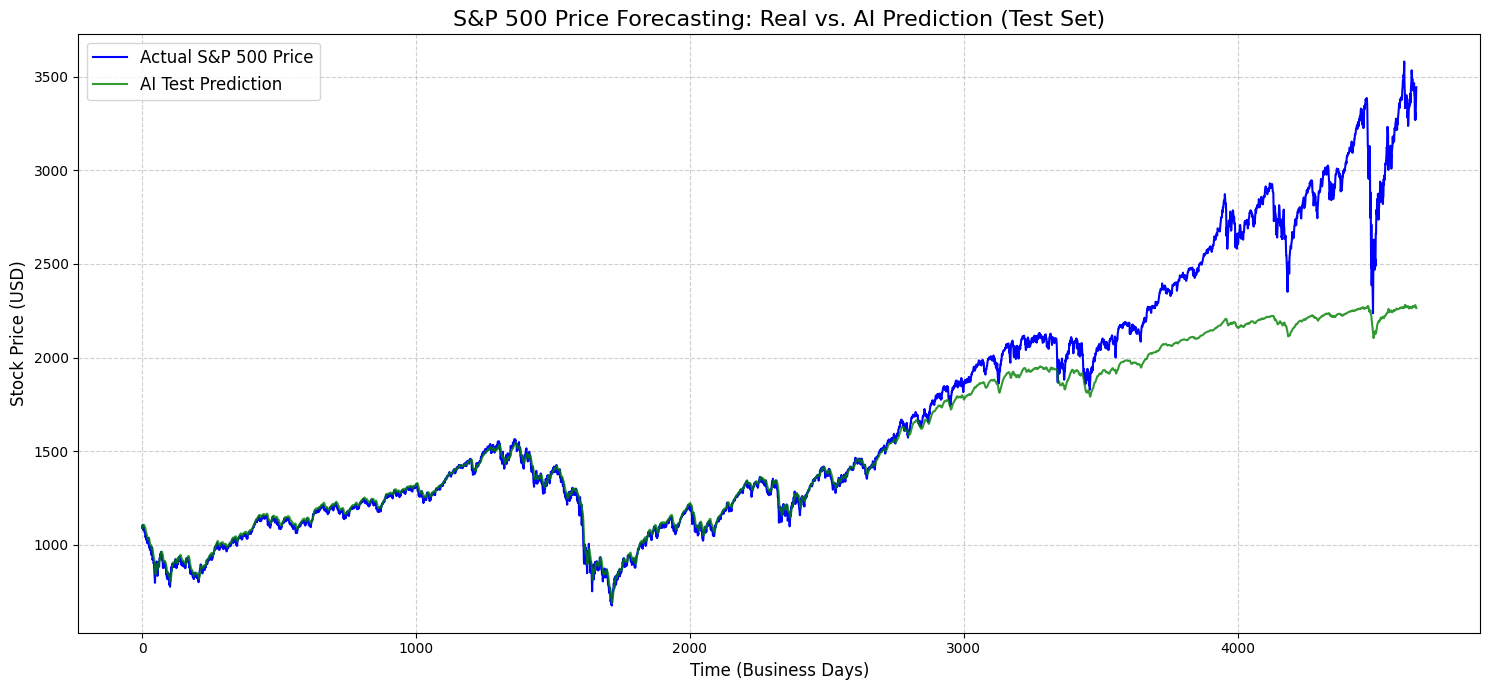

In [22]:
import matplotlib.pyplot as plt

# 1. Generate predictions using the optimized model
test_predictions = model_optimized.predict(X_test)

# 2. Revert the scaling to get actual USD values
# This transforms the [0, 1] range back to the real S&P 500 price range
test_predictions = scaler.inverse_transform(test_predictions)
y_test_actual = scaler.inverse_transform(y_test.reshape(-1, 1))

# 3. Professional Visualization
plt.figure(figsize=(15, 7))

# Plotting the Real vs Predicted
plt.plot(y_test_actual, color='blue', label='Actual S&P 500 Price', linewidth=1.5)
plt.plot(test_predictions, color='green', label='AI Test Prediction', linewidth=1.5, alpha=0.8)

# Adding Title and Axis Labels (English)
plt.title('S&P 500 Price Forecasting: Real vs. AI Prediction (Test Set)', fontsize=16)
plt.xlabel('Time (Business Days)', fontsize=12) # X-axis
plt.ylabel('Stock Price (USD)', fontsize=12)        # Y-axis

# Enhancement features for the report
plt.legend(loc='upper left', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6) # Adds a grid for better readability

plt.tight_layout()
# Save the figure as a high-resolution PNG
plt.savefig('sp500_prediction_plot.png', dpi=300)

# Then show it
plt.show()

In [23]:
import numpy as np
import pandas as pd

# 1. Calculate Daily Returns: (Price_today / Price_yesterday) - 1
data['Returns'] = data['Close'].pct_change()
data.dropna(inplace=True) # Remove the first row which becomes NaN

# 2. Scale the Returns
# Returns are usually very small (e.g., 0.01), so we scale them for the LSTM
from sklearn.preprocessing import StandardScaler
scaler_ret = StandardScaler()
scaled_returns = scaler_ret.fit_transform(data[['Returns']].values)

# 3. Create Windows (Same 60-day logic)
X_ret, y_ret = [], []
for i in range(60, len(scaled_returns)):
    X_ret.append(scaled_returns[i-60:i, 0])
    y_ret.append(scaled_returns[i, 0])

X_ret, y_ret = np.array(X_ret), np.array(y_ret)
X_ret = np.reshape(X_ret, (X_ret.shape[0], X_ret.shape[1], 1))

# Split into Train and Test (80/20)
split = int(len(X_ret) * 0.8)
X_train_ret, X_test_ret = X_ret[:split], X_ret[split:]
y_train_ret, y_test_ret = y_ret[:split], y_ret[split:]

print("Returns data ready for training!")

Returns data ready for training!


In [24]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, Dropout

model_ret = Sequential()

model_ret.add(LSTM(units=50, return_sequences=True, input_shape=(60, 1)))
model_ret.add(Dropout(0.2))

model_ret.add(LSTM(units=50, return_sequences=False))
model_ret.add(Dropout(0.2))

model_ret.add(Dense(units=1))
model_ret.compile(optimizer='adam', loss='mean_squared_error')

# Train for 20 epochs
model_ret.fit(X_train_ret, y_train_ret, epochs=20, batch_size=32)

Epoch 1/20


c:\Users\HP\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


582/582 ━━━━━━━━━━━━━━━━━━━━ 19s 28ms/step - loss: 0.9842
Epoch 2/20
582/582 ━━━━━━━━━━━━━━━━━━━━ 17s 29ms/step - loss: 0.9842
Epoch 3/20
582/582 ━━━━━━━━━━━━━━━━━━━━ 16s 27ms/step - loss: 0.9826
Epoch 4/20
582/582 ━━━━━━━━━━━━━━━━━━━━ 16s 28ms/step - loss: 0.9826
Epoch 5/20
582/582 ━━━━━━━━━━━━━━━━━━━━ 16s 28ms/step - loss: 0.9798
Epoch 6/20
582/582 ━━━━━━━━━━━━━━━━━━━━ 16s 28ms/step - loss: 0.9790
Epoch 7/20
582/582 ━━━━━━━━━━━━━━━━━━━━ 16s 28ms/step - loss: 0.9768
Epoch 8/20
582/582 ━━━━━━━━━━━━━━━━━━━━ 16s 27ms/step - loss: 0.9725
Epoch 9/20
582/582 ━━━━━━━━━━━━━━━━━━━━ 16s 28ms/step - loss: 0.9698
Epoch 10/20
582/582 ━━━━━━━━━━━━━━━━━━━━ 17s 29ms/step - loss: 0.9682
Epoch 11/20
582/582 ━━━━━━━━━━━━━━━━━━━━ 16s 28ms/step - loss: 0.9643
Epoch 12/20
582/582 ━━━━━━━━━━━━━━━━━━━━ 17s 29ms/step - loss: 0.9629
Epoch 13/20
582/582 ━━━━━━━━━━━━━━━━━━━━ 16s 27ms/step - loss: 0.9554
Epoch 14/20
582/582 ━━━━━━━━━━━━━━━━━━━━ 16s 27ms/step - loss: 0.9516
Epoch 15/20
582/582 ━━━━━━━━━━━━━━━━━━━━

146/146 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step
Graph saved successfully as SP500_OptionA_Results.png


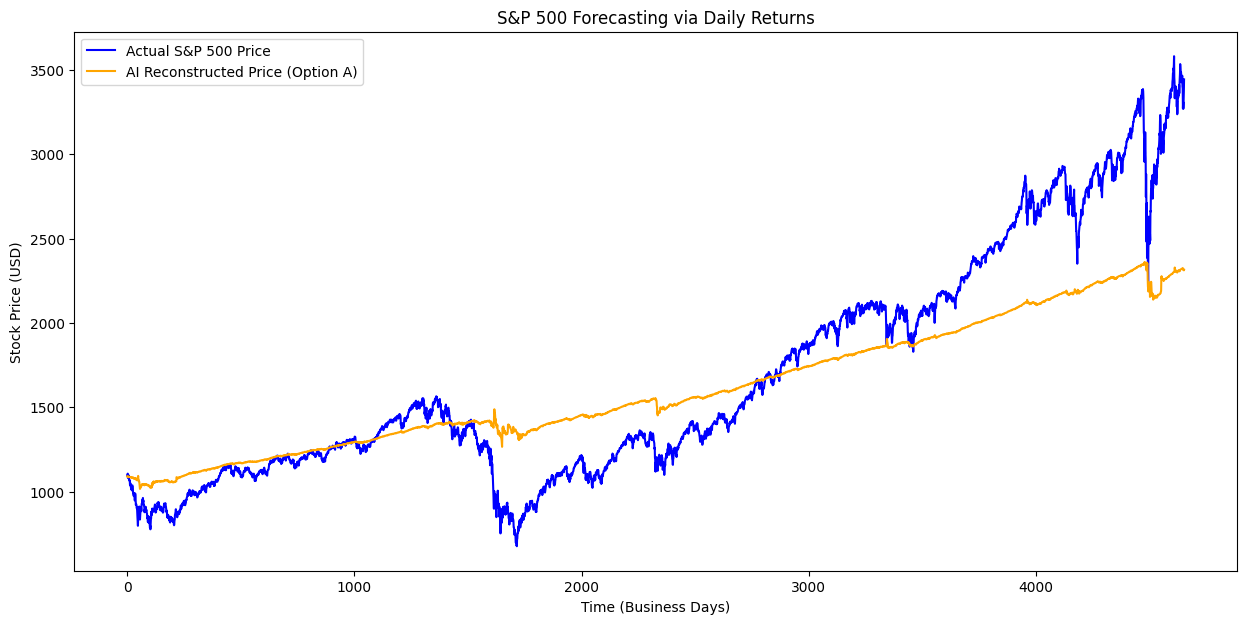

In [25]:
# 1. Predict Returns
pred_returns_scaled = model_ret.predict(X_test_ret)
pred_returns = scaler_ret.inverse_transform(pred_returns_scaled)

# 2. Reconstruct Prices
# We need the starting price of the test set
test_start_price = data['Close'].iloc[split + 60]
predicted_prices = [test_start_price]

for i in range(len(pred_returns)):
    new_price = predicted_prices[-1] * (1 + pred_returns[i][0])
    predicted_prices.append(new_price)

# 3. Plotting
plt.figure(figsize=(15, 7))
actual_prices = data['Close'].iloc[split+60:].values
plt.plot(actual_prices, color='blue', label='Actual S&P 500 Price')
plt.plot(predicted_prices[:-1], color='orange', label='AI Reconstructed Price (Option A)')
plt.title('S&P 500 Forecasting via Daily Returns')
plt.xlabel('Time (Business Days)')
plt.ylabel('Stock Price (USD)')
plt.legend()# This saves the file directly to your project folder
plt.savefig('SP500_OptionA_Results.png', dpi=300, bbox_inches='tight')
print("Graph saved successfully as SP500_OptionA_Results.png")

plt.show()

Graph saved successfully as SP500_OptionA_Results.png


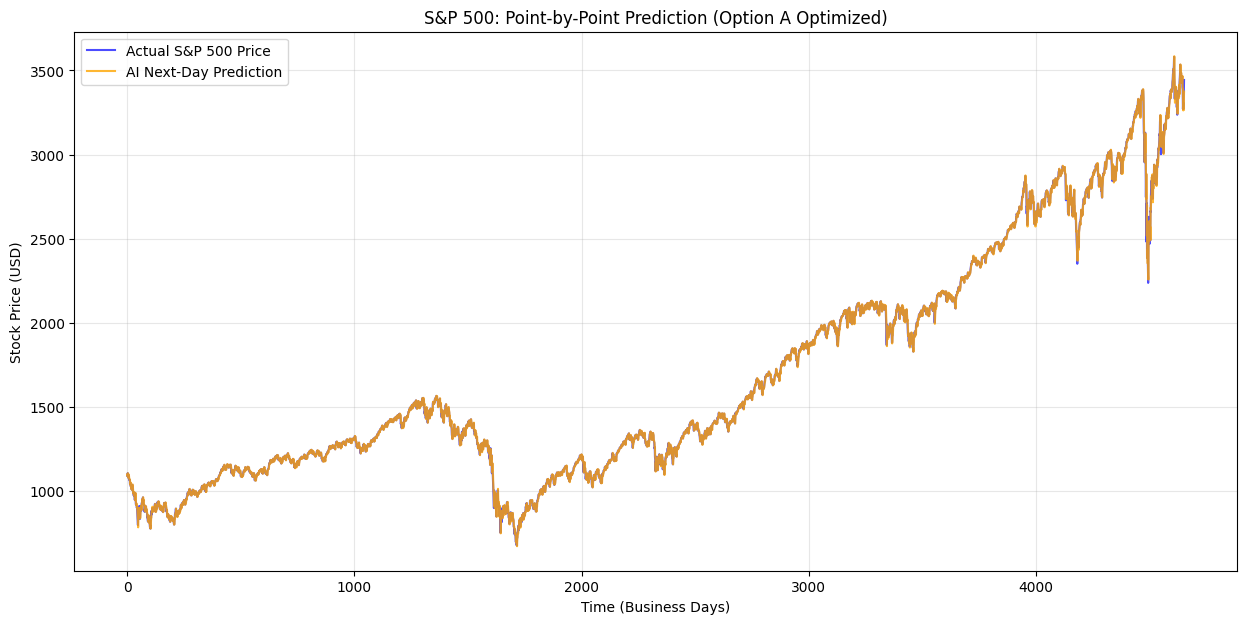

In [26]:
# 1. Get the actual prices for each 'tomorrow'
actual_prices = data['Close'].iloc[split+60:].values

# 2. Predict 'tomorrow' using 'today's' REAL price (Point-by-point)
# This prevents the compounding error
point_by_point_preds = []
for i in range(len(pred_returns)):
    # Use the ACTUAL price of the previous day from the dataset
    last_actual_price = data['Close'].iloc[split + 60 + i - 1]
    prediction = last_actual_price * (1 + pred_returns[i][0])
    point_by_point_preds.append(prediction)

# 3. Plotting
plt.figure(figsize=(15, 7))
plt.plot(actual_prices, color='blue', label='Actual S&P 500 Price', alpha=0.7)
plt.plot(point_by_point_preds, color='orange', label='AI Next-Day Prediction', alpha=0.8)
plt.title('S&P 500: Point-by-Point Prediction (Option A Optimized)')
plt.xlabel('Time (Business Days)')
plt.ylabel('Stock Price (USD)')
plt.legend()
plt.grid(True, alpha=0.3)

plt.savefig('SP500_OptionA_Results_fixed.png', dpi=300, bbox_inches='tight')
print("Graph saved successfully as SP500_OptionA_Results.png")

plt.show()

In [27]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# 1. Convert lists to numpy arrays for calculation
actual_np = np.array(actual_prices)
preds_np = np.array(point_by_point_preds)

# 2. Mean Absolute Error (MAE)
# Represents the average dollar amount the AI is off by
mae = mean_absolute_error(actual_np, preds_np)

# 3. Root Mean Squared Error (RMSE)
# Penalizes larger errors more heavily (important for high volatility)
rmse = np.sqrt(mean_squared_error(actual_np, preds_np))

# 4. Mean Absolute Percentage Error (MAPE)
# Shows the error as a percentage of the actual price
mape = np.mean(np.abs((actual_np - preds_np) / actual_np)) * 100

print(f"--- Model Evaluation Results ---")
print(f"Mean Absolute Error (MAE): ${mae:.2f}")
print(f"Root Mean Squared Error (RMSE): ${rmse:.2f}")
print(f"Mean Absolute Percentage Error (MAPE): {mape:.2f}%")

--- Model Evaluation Results ---
Mean Absolute Error (MAE): $12.73
Root Mean Squared Error (RMSE): $21.07
Mean Absolute Percentage Error (MAPE): 0.81%


In [28]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler

# 1. Veriyi ve Scaler'ı o anlık hazırla (Hata almamak için)
data['Returns'] = data['Close'].pct_change()
temp_data = data['Returns'].dropna().values.reshape(-1, 1)
temp_scaler = StandardScaler().fit(temp_data)

# 2. Son 60 günlük pencereyi oluştur
last_60_days = data['Returns'].values[-60:]
last_60_days_scaled = temp_scaler.transform(last_60_days.reshape(-1, 1))
live_input = last_60_days_scaled.reshape(1, 60, 1)

# 3. Fiyatlar
wednesday_price = 7137.90
thursday_actual = 7108.40

# 4. Tahmin (Hangi model ismindeyse onu kullanır)
try:
    if 'model_ret' in locals():
        pred_scaled = model_ret.predict(live_input)
    elif 'model_optimized' in locals():
        pred_scaled = model_optimized.predict(live_input)
    else:
        # Eğer hiçbiri yoksa en son eğitilen modeli bulmaya çalışır
        pred_scaled = model.predict(live_input)

    # Ölçeği geri çevir ve fiyatı hesapla
    predicted_return = temp_scaler.inverse_transform(pred_scaled)[0][0]
    thursday_predicted = wednesday_price * (1 + predicted_return)

    # SONUÇLARI YAZDIR
    print(f"--- Live Challenge Results ---")
    print(f"Wednesday Actual: ${wednesday_price:,.2f}")
    print(f"Thursday Actual:  ${thursday_actual:,.2f}")
    print(f"AI Prediction for Thursday: ${thursday_predicted:,.2f}")

    error = abs(thursday_actual - thursday_predicted)
    print(f"\nAbsolute Error: ${error:.2f}")

except Exception as e:
    print(f"Hala bir eksik var: {e}")
    print("Not: Eğer 'model' bulunamadı diyorsa, lütfen yukarıdaki 'model.fit' hücresini tekrar çalıştır.")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
--- Live Challenge Results ---
Wednesday Actual: $7,137.90
Thursday Actual:  $7,108.40
AI Prediction for Thursday: $7,141.45

Absolute Error: $33.05
